In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
import random
from tqdm.autonotebook import tqdm
import seaborn as sns
from envs import NonStationaryEnv
from basal_ganglia import train
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_4496/2656916288.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [ ]:
# Hyperparameters
TRAILS = 150
EPOCHS = 50
BINS = 15
LR = 0.1
NUM_ARMS = 3
SCALING_FACTOR = 100
TIME_STAMP_CHANGE = 75
BIN_SIZE = TRAILS // BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE
cases = ['PD', 'std DBS', 'Open loop low amp', 'Open loop high amp', 'closed loop']
dbs_conds=[None, 'standard_dbs', 'open_loop_low', 'open_loop_high', 'closed_loop'] # for running train loop
del_lim = [0.05, 0.2, 0.8, 1]
Results_dict = {key: {value: [] for value in del_lim} for key in cases}

In [ ]:
for i in range(len(cases)):
    case = cases[i]
    dbs_cond = dbs_conds[i]
    for j in range(len(del_lim)):
        delta = del_lim[j]
        print(f"Running case: {case}, dbs_cond: {dbs_cond}, delta: {delta}")
        
        env = NonStationaryEnv(
        num_arms=NUM_ARMS,
        mean_reward=np.array([20, 40, 30]) / SCALING_FACTOR,
        std=np.array([5,5,5]) / SCALING_FACTOR,
        mean_rew_change=np.array([10, 35, 40]) / SCALING_FACTOR,
        std_change=np.array([5,5,5]) / SCALING_FACTOR,
        time_stamp_change=TIME_STAMP_CHANGE)
        
        BEST_ARM_BEFORE = 1
        BEST_ARM_AFTER = 2
        BEST_ARM = torch.zeros((EPOCHS, TRAILS), dtype=int)
        BEST_ARM[:, :TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
        BEST_ARM[:, TIME_STAMP_CHANGE:] = BEST_ARM_AFTER
        # Training
        reward_monitor, arm_chosen_monitor, avg_counts, ip_monitor, dp_monitor, ep_monitor = train(
                    env,
                    trails=TRAILS,
                    epochs=EPOCHS,
                    lr=LR,
                    bins=BINS,
                    STN_data='rossler',
                    dbs_cond=dbs_cond,
                    d1_amp=0.7,
                    d2_amp=0.01, 
                    gpi_threshold=0.3,
                    max_gpi_iters=50,
                    del_lim=delta,
                    train_IP=False,
                    del_med=None,
                    printing=False,
                    gpi_mean=1,
                    ep_0=0.3,
                    alpha_ep=0.0,
                    eta_ep=0.1,
                    baseline_ep=0.0,
                    ep_lim=0.1,
                )

        arm_chosen_monitor = arm_chosen_monitor.to(torch.int)
        accuracy_percentages = torch.zeros((EPOCHS, BINS))
        for i in range(BINS):
            start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
            correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:, start:end], axis=1)
            accuracy_percentages[:, i] = (correct_choices / BIN_SIZE) * 100

        Results_dict[case][delta] = accuracy_percentages.numpy()
        

In [4]:
last_bin_accuracies_dict = {case: [] for case in cases}
for case in cases:
    accuracy_mon = []
    for delta in del_lim:
        accuracies_avg = Results_dict[case][delta].mean(axis=0) #(20, 15)
        accuracies_avg_last_bin = accuracies_avg[-1]
        accuracy_mon.append(accuracies_avg_last_bin)
    last_bin_accuracies_dict[case] = accuracy_mon


In [5]:
for case in last_bin_accuracies_dict:
    last_bin_accuracies_dict[case] = [1 if x == 0 else x for x in last_bin_accuracies_dict[case]]

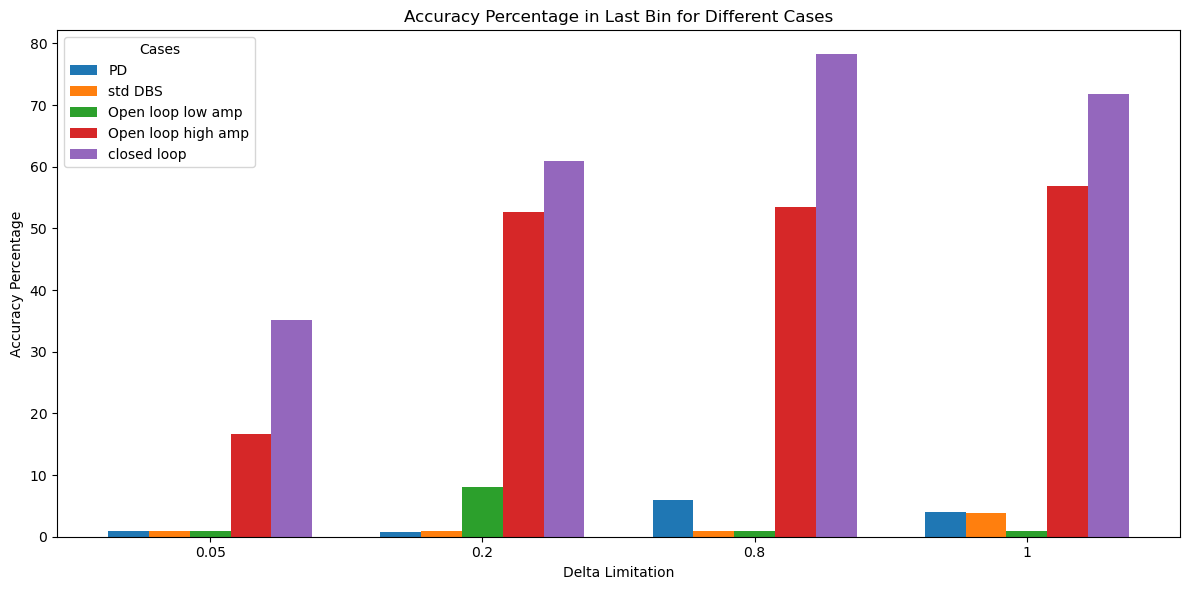

In [6]:
# bar plot for last bin accuracies one after the other for all 5 cases where x axis is del_lim and y axis is accuracy percentage
x = np.arange(len(del_lim))  # the label locations
width = 0.15  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, case in enumerate(cases):
    ax.bar(x + i * width, last_bin_accuracies_dict[case], width, label=case)
ax.set_xlabel('Delta Limitation')
ax.set_ylabel('Accuracy Percentage')
ax.set_title('Accuracy Percentage in Last Bin for Different Cases')
ax.set_xticks(x + width * (len(cases) - 1) /2)
ax.set_xticklabels(del_lim)
ax.legend(title='Cases')
plt.tight_layout()


In [7]:
Results_dict['closed loop'][1].mean(0)

array([76.8, 80.8, 80. , 82.2, 89.8, 92. , 88.4, 46. , 38.2, 66.6, 57.8,
       61.8, 65.4, 62.2, 71.8], dtype=float32)

In [ ]:
# # saving pickle file
# with open('results_non_stationary_bandits.pkl', 'wb') as f:
#     pickle.dump(Results_dict, f)